# IMPORT

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_hist_gradient_boosting  
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from matplotlib.patches import ConnectionPatch

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

D:\nest\venv\Lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:18: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [3]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# READING DATA

In [4]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')
df_sub = pd.read_csv('data/sample_submission.csv')

In [5]:
df_train.shape

(58645, 13)

In [6]:
df_train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [7]:
df_train.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [8]:
df_test.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,58645,23,69000,RENT,3.0,HOMEIMPROVEMENT,F,25000,15.76,0.36,N,2
1,58646,26,96000,MORTGAGE,6.0,PERSONAL,C,10000,12.68,0.10,Y,4
2,58647,26,30000,RENT,5.0,VENTURE,E,4000,17.19,0.13,Y,2
3,58648,33,50000,RENT,4.0,DEBTCONSOLIDATION,A,7000,8.90,0.14,N,7
4,58649,26,102000,MORTGAGE,8.0,HOMEIMPROVEMENT,D,15000,16.32,0.15,Y,4


In [9]:
df_sub.head()

,id,loan_status
0,58645,0.5
1,58646,0.5
2,58647,0.5
3,58648,0.5
4,58649,0.5


In [10]:
df_train = df_train.drop(columns=['id'])
df_test = df_test.drop(columns=['id'])

In [11]:
df_train.shape,df_test.shape

((58645, 12), (39098, 11))

In [12]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58645 non-null  int64  
 1   person_income               58645 non-null  int64  
 2   person_home_ownership       58645 non-null  str    
 3   person_emp_length           58645 non-null  float64
 4   loan_intent                 58645 non-null  str    
 5   loan_grade                  58645 non-null  str    
 6   loan_amnt                   58645 non-null  int64  
 7   loan_int_rate               58645 non-null  float64
 8   loan_percent_income         58645 non-null  float64
 9   cb_person_default_on_file   58645 non-null  str    
 10  cb_person_cred_hist_length  58645 non-null  int64  
 11  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 5.4 MB


In [13]:
df_train.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [14]:
df_test.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [15]:
df_train['person_emp_length'].fillna(df_train['person_emp_length'].mean(), inplace=True)
df_train['loan_int_rate'].fillna(df_train['loan_int_rate'].mean(), inplace=True)

C:\Users\linet\AppData\Local\Temp\ipykernel_21744\1278148906.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_train['person_emp_length'].fillna(df_train['person_emp_length'].mean(), inplace=True)
C:\Users\linet\AppData\Local\Temp\ipykernel_21744\1278148906.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFr

0        11.49
1        13.35
2         8.90
3        11.11
4         6.92
         ...  
58640    15.95
58641    12.73
58642    16.00
58643     8.90
58644    11.11
Name: loan_int_rate, Length: 58645, dtype: float64

In [16]:
df_train.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

# EXPLORATORY DATA ANALYSIS

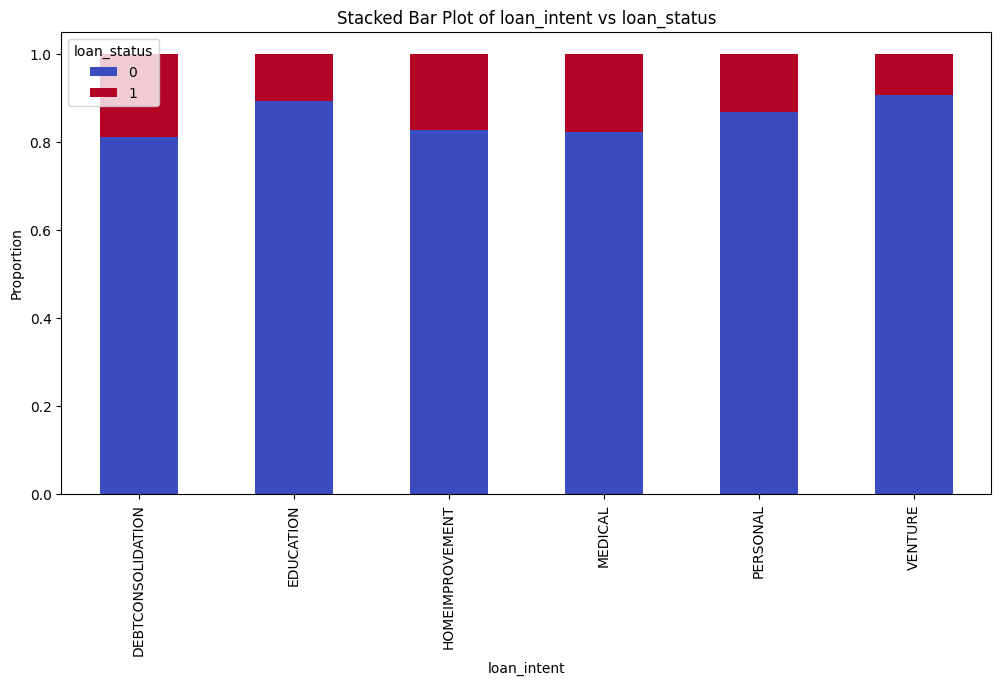

In [17]:
def stacked_bar_plot(df, feature, target='loan_status'):
    crosstab = pd.crosstab(df[feature], df[target], normalize='index')
    crosstab.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='coolwarm')
    plt.title(f'Stacked Bar Plot of {feature} vs {target}')
    plt.ylabel('Proportion')
    plt.show()
stacked_bar_plot(df_train, 'loan_intent')

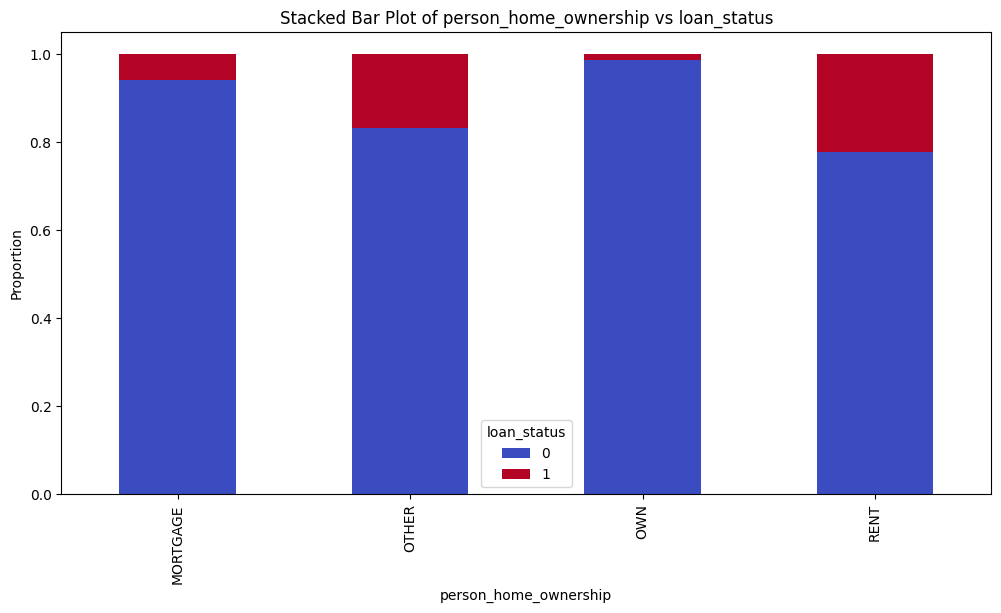

In [18]:
stacked_bar_plot(df_train, 'person_home_ownership')

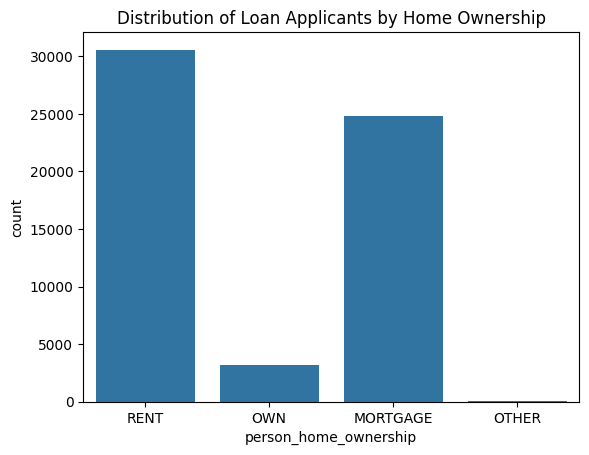

In [19]:
sns.countplot(data=df_train, x='person_home_ownership')
plt.title('Distribution of Loan Applicants by Home Ownership')
plt.show()

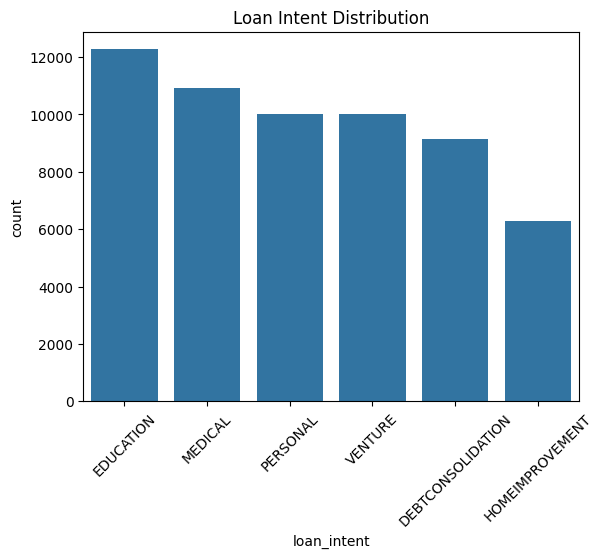

In [20]:
sns.countplot(data=df_train, x='loan_intent')
plt.title('Loan Intent Distribution')
plt.xticks(rotation=45)
plt.show()

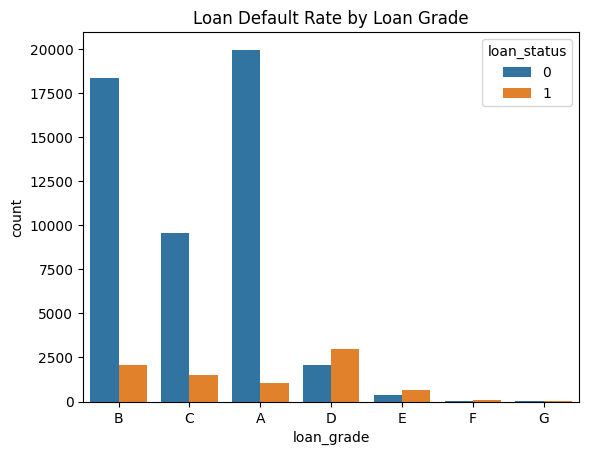

In [21]:
sns.countplot(data=df_train, x='loan_grade', hue='loan_status')
plt.title('Loan Default Rate by Loan Grade')
plt.show()

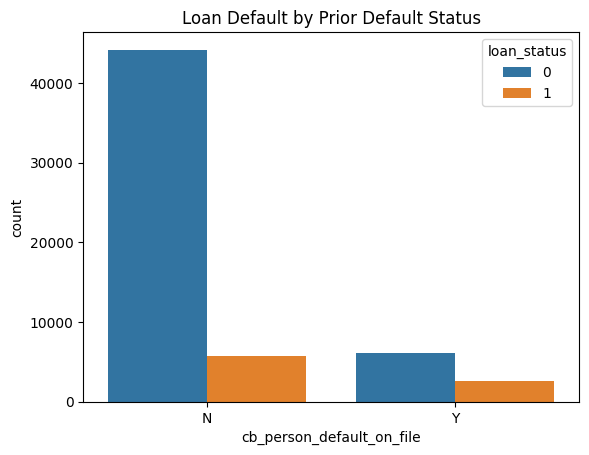

In [22]:
sns.countplot(data=df_train, x='cb_person_default_on_file', hue='loan_status')
plt.title('Loan Default by Prior Default Status')
plt.show()

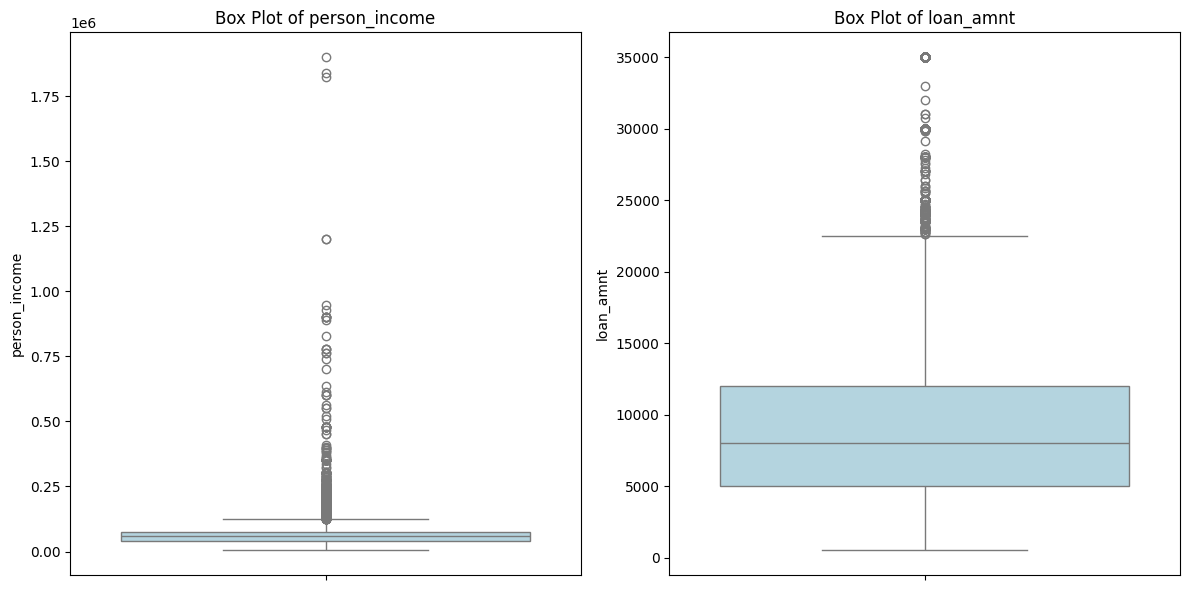

In [23]:
def plot_boxplots(df, columns):
    plt.figure(figsize=(12, 6))
    for i, col in enumerate(columns, 1):
        plt.subplot(1, len(columns), i)
        sns.boxplot(y=df[col], color='lightblue')
        plt.title(f'Box Plot of {col}')
    plt.tight_layout()
    plt.show()

plot_boxplots(df_train, ['person_income', 'loan_amnt'])

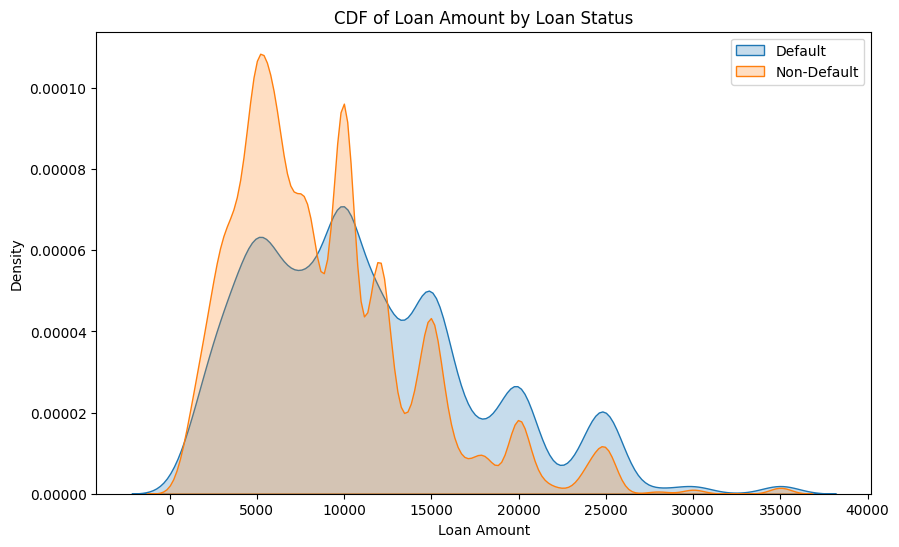

In [24]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_train[df_train['loan_status'] == 1]['loan_amnt'], label='Default', fill=True)
sns.kdeplot(df_train[df_train['loan_status'] == 0]['loan_amnt'], label='Non-Default', fill=True)
plt.title('CDF of Loan Amount by Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Density')
plt.legend()
plt.show()

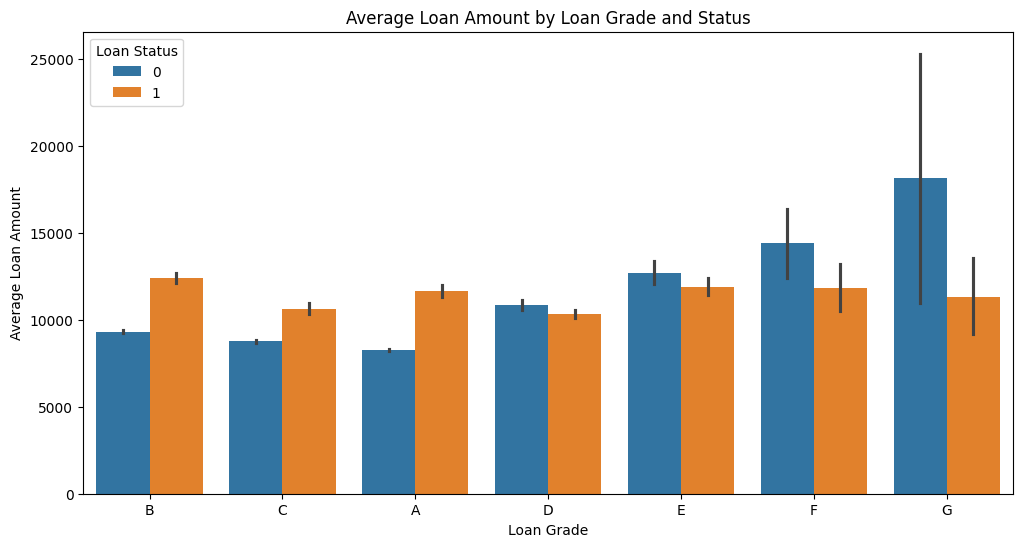

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(x='loan_grade', y='loan_amnt', hue='loan_status', data=df_train, estimator=np.mean)
plt.title('Average Loan Amount by Loan Grade and Status')
plt.xlabel('Loan Grade')
plt.ylabel('Average Loan Amount')
plt.legend(title='Loan Status')
plt.show()

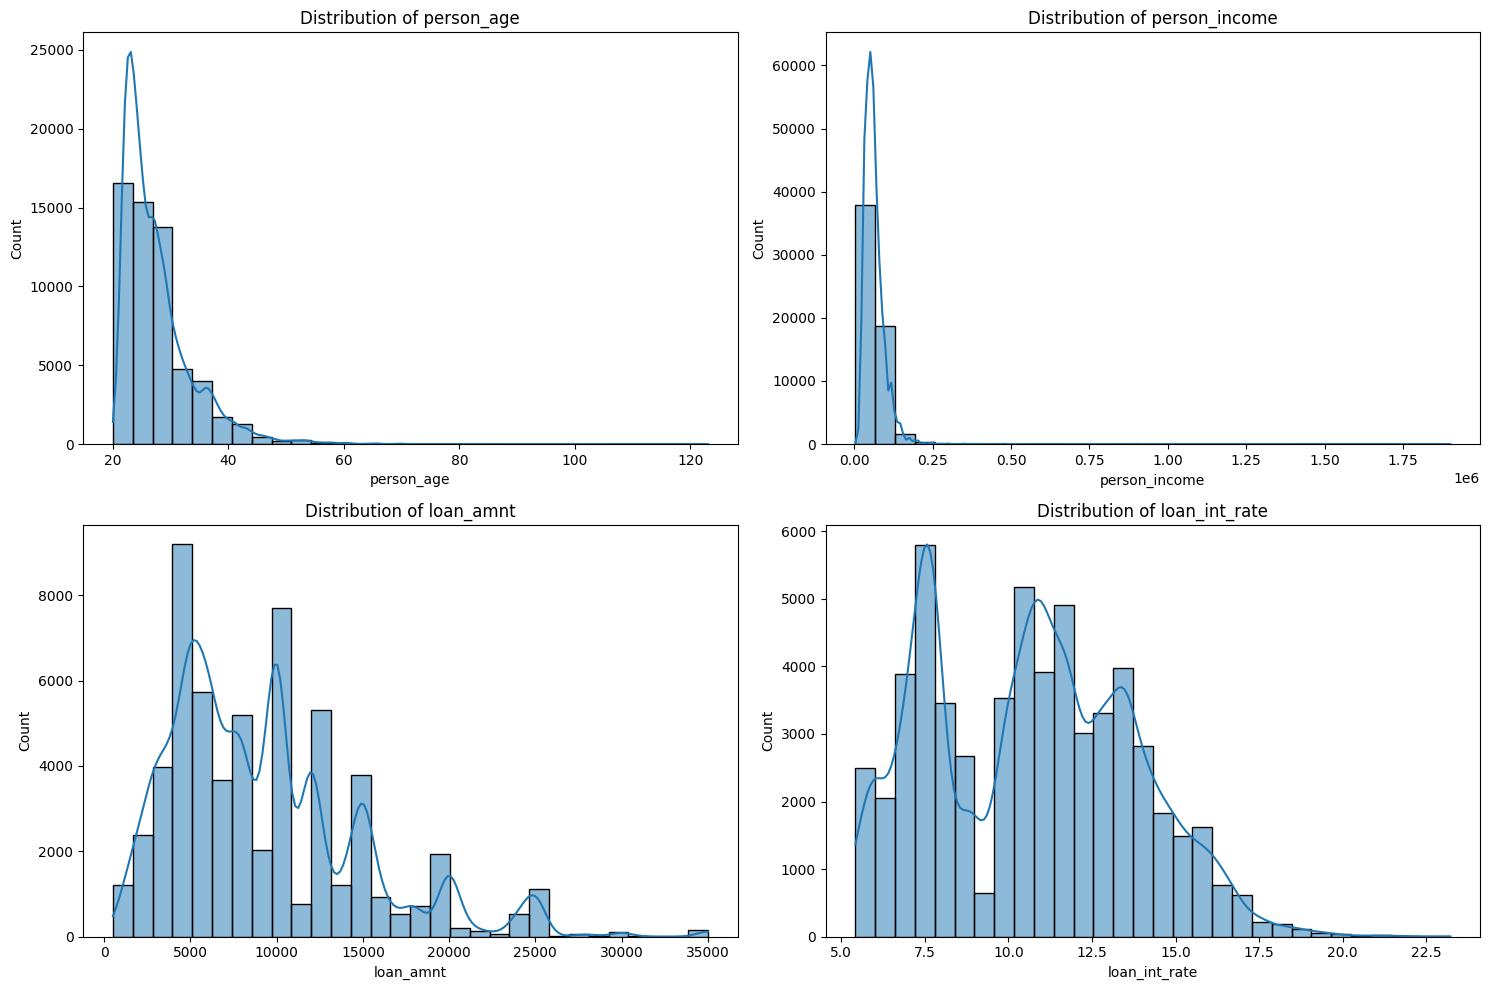

In [26]:
num_features = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(num_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_train[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

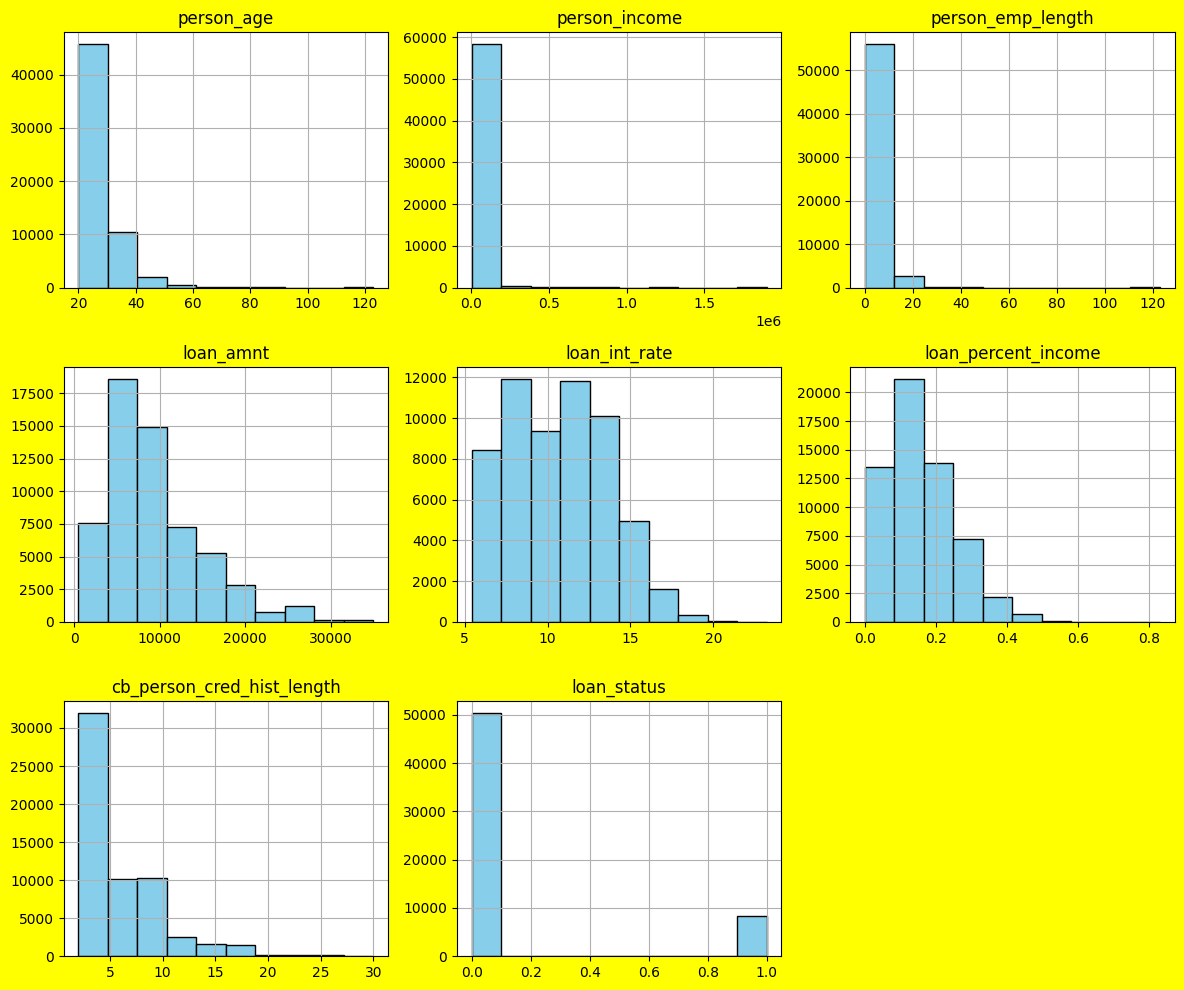

In [27]:
df_train.hist(figsize=(12, 10), color='skyblue', edgecolor='black')
plt.gcf().set_facecolor('yellow')
plt.tight_layout()
plt.show()

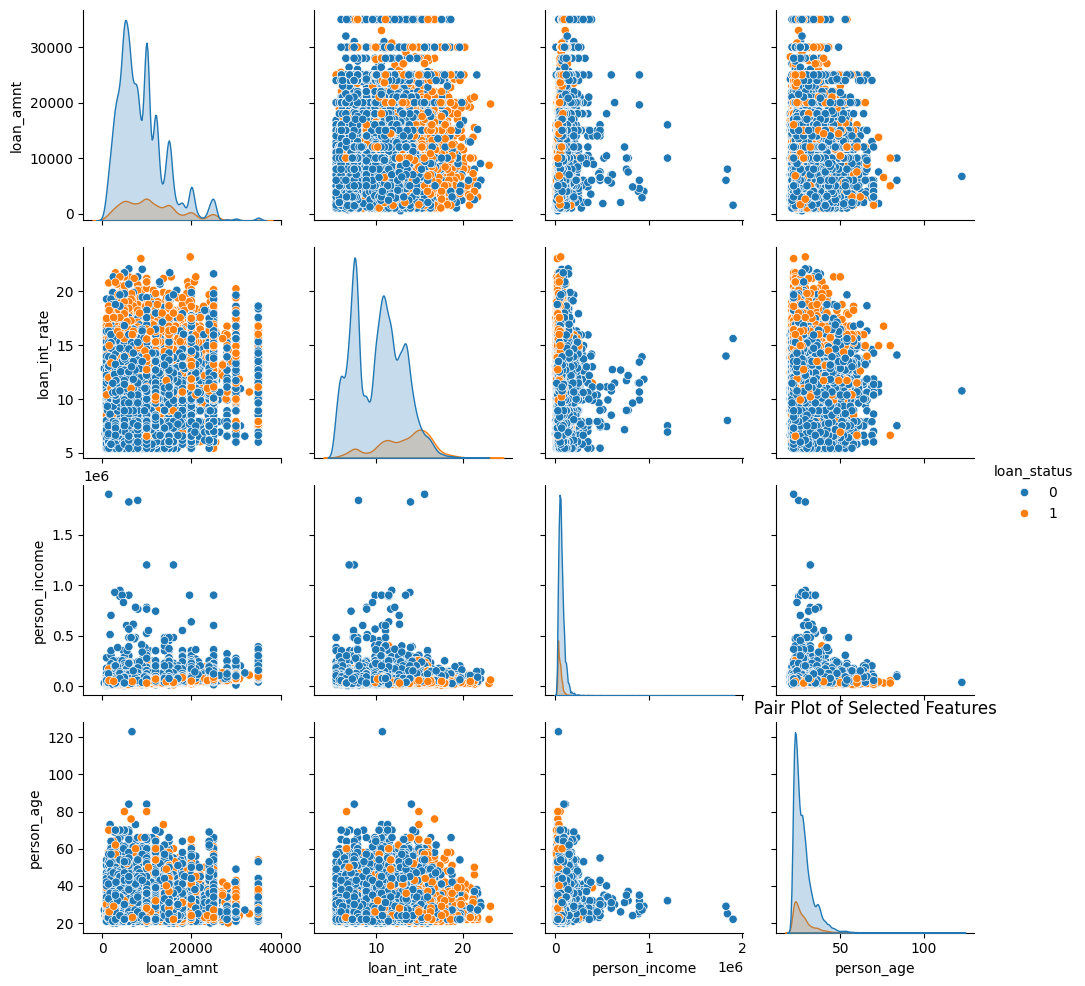

In [28]:
subset_features = ['loan_amnt', 'loan_int_rate', 'person_income', 'person_age', 'loan_status']
sns.pairplot(df_train[subset_features], hue='loan_status')
plt.title('Pair Plot of Selected Features')
plt.show()

In [29]:
from sklearn.preprocessing import LabelEncoder

def preprocess_data(df_train, df_test):  
    label_enc = LabelEncoder()   
    label_cols = ['person_home_ownership', 'loan_grade', 'cb_person_default_on_file']    
    for col in label_cols:
        df_train[col] = label_enc.fit_transform(df_train[col])
        df_test[col] = label_enc.transform(df_test[col])    
    df_train = pd.get_dummies(df_train, columns=['loan_intent'], drop_first=True)
    df_test = pd.get_dummies(df_test, columns=['loan_intent'], drop_first=True) 
    target_col = 'loan_status'
    train_columns = df_train.drop(columns=[target_col]).columns    
    df_test = df_test.reindex(columns=train_columns, fill_value=0)    
    return df_train, df_test

df_train_processed, df_test_processed = preprocess_data(df_train, df_test)

In [30]:
from sklearn.preprocessing import LabelEncoder

for col in ['person_home_ownership',
            'loan_grade',
            'cb_person_default_on_file']:

    le = LabelEncoder()
    le.fit(df_train[col])

    print(f"\n{col}")
    print(dict(zip(le.classes_,
                   le.transform(le.classes_))))


person_home_ownership
{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}

loan_grade
{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6)}

cb_person_default_on_file
{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


In [63]:
print(df_train_processed.head())

   person_age  person_income  person_home_ownership  person_emp_length  \
0          37          35000                      3                0.0   
1          22          56000                      2                6.0   
2          29          28800                      2                8.0   
3          30          70000                      3               14.0   
4          22          60000                      3                2.0   

   loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
0           1       6000          11.49                 0.17   
1           2       4000          13.35                 0.07   
2           0       6000           8.90                 0.21   
3           1      12000          11.11                 0.17   
4           0       6000           6.92                 0.10   

   cb_person_default_on_file  cb_person_cred_hist_length  ...  \
0                          0                          14  ...   
1                          0            

In [64]:
df_original = pd.read_csv("data/train.csv")

print(df_original["person_home_ownership"].unique())
print(df_original["loan_grade"].unique())
print(df_original["cb_person_default_on_file"].unique())

<StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str
<StringArray>
['B', 'C', 'A', 'D', 'E', 'F', 'G']
Length: 7, dtype: str
<StringArray>
['N', 'Y']
Length: 2, dtype: str


In [31]:
df_train = df_train_processed
df_test = df_test_processed

In [32]:
df_train.shape,df_test.shape

((58645, 16), (39098, 15))

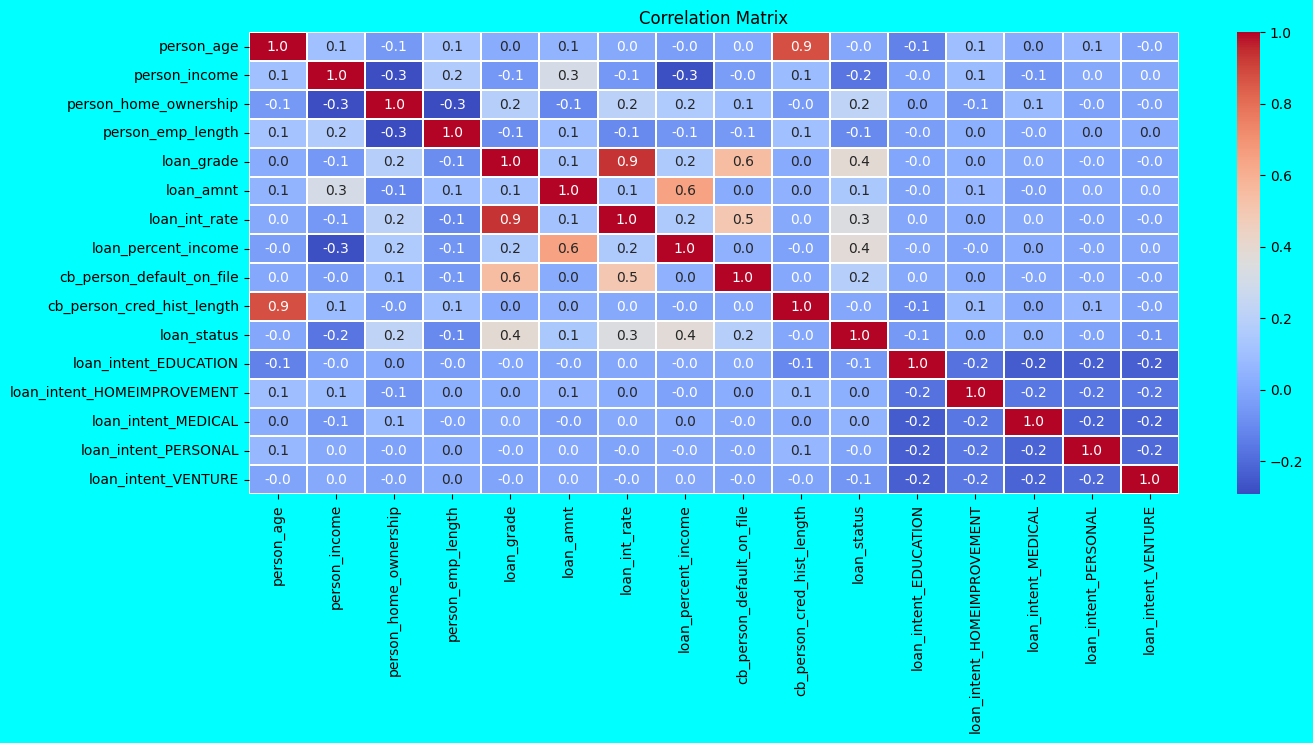

In [33]:
correlation_matrix = df_train.corr()
plt.figure(figsize=(15, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.2)
plt.gcf().set_facecolor('#00FFFF')  
plt.title('Correlation Matrix')
plt.show()

# REGRESSION ANALYSIS

In [34]:
df_train.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE'],
      dtype='str')

In [35]:
df_test.isnull().sum()

person_age                     0
person_income                  0
person_home_ownership          0
person_emp_length              0
loan_grade                     0
loan_amnt                      0
loan_int_rate                  0
loan_percent_income            0
cb_person_default_on_file      0
cb_person_cred_hist_length     0
loan_intent_EDUCATION          0
loan_intent_HOMEIMPROVEMENT    0
loan_intent_MEDICAL            0
loan_intent_PERSONAL           0
loan_intent_VENTURE            0
dtype: int64

In [36]:
def feature_engineering(df):
    
    df['loan_to_income_ratio'] = df['loan_amnt'] / df['person_income']  
    df['financial_burden'] = df['loan_amnt'] * df['loan_int_rate'] 
    df['income_per_year_emp'] = df['person_income'] / (df['person_emp_length'])
    df['cred_hist_to_age_ratio'] = df['cb_person_cred_hist_length'] / df['person_age']
    df['int_to_loan_ratio'] = df['loan_int_rate'] / df['loan_amnt']
    df['loan_int_emp_interaction'] = df['loan_int_rate'] * df['person_emp_length']
    df['debt_to_credit_ratio'] = df['loan_amnt'] / df['cb_person_cred_hist_length'] 
    df['int_to_cred_hist'] = df['loan_int_rate'] / df['cb_person_cred_hist_length']  
    df['int_per_year_emp'] = df['loan_int_rate'] / (df['person_emp_length'])
    df['loan_amt_per_emp_year'] = df['loan_amnt'] / (df['person_emp_length'])      
    df['income_to_loan_ratio'] = df['person_income'] / df['loan_amnt'] 
    
    return df

#median_income = df_train['person_income'].median()
df_train = feature_engineering(df_train)
df_test = feature_engineering(df_test)

In [37]:
y = df_train['loan_status'] 
df_train = df_train.drop(['loan_status'],axis=1)
X = df_train

# SCALING

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_train_data = df_train
scaled_test_data = df_test

In [39]:
scaled_train_data

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,financial_burden,income_per_year_emp,cred_hist_to_age_ratio,int_to_loan_ratio,loan_int_emp_interaction,debt_to_credit_ratio,int_to_cred_hist,int_per_year_emp,loan_amt_per_emp_year,income_to_loan_ratio
0,37,35000,3,0.0,1,6000,11.49,0.17,0,14,...,68940.0,inf,0.378378,0.001915,0.00,428.571429,0.820714,inf,inf,5.833333
1,22,56000,2,6.0,2,4000,13.35,0.07,0,2,...,53400.0,9.333333e+03,0.090909,0.003337,80.10,2000.000000,6.675000,2.225000,666.666667,14.000000
2,29,28800,2,8.0,0,6000,8.90,0.21,0,10,...,53400.0,3.600000e+03,0.344828,0.001483,71.20,600.000000,0.890000,1.112500,750.000000,4.800000
3,30,70000,3,14.0,1,12000,11.11,0.17,0,5,...,133320.0,5.000000e+03,0.166667,0.000926,155.54,2400.000000,2.222000,0.793571,857.142857,5.833333
4,22,60000,3,2.0,0,6000,6.92,0.10,0,3,...,41520.0,3.000000e+04,0.136364,0.001153,13.84,2000.000000,2.306667,3.460000,3000.000000,10.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,34,120000,0,5.0,3,25000,15.95,0.21,1,10,...,398750.0,2.400000e+04,0.294118,0.000638,79.75,2500.000000,1.595000,3.190000,5000.000000,4.800000
58641,28,28800,3,0.0,2,10000,12.73,0.35,0,8,...,127300.0,inf,0.285714,0.001273,0.00,1250.000000,1.591250,inf,inf,2.880000
58642,23,44000,3,7.0,3,6800,16.00,0.15,0,2,...,108800.0,6.285714e+03,0.086957,0.002353,112.00,3400.000000,8.000000,2.285714,971.428571,6.470588
58643,22,30000,3,2.0,0,5000,8.90,0.17,0,3,...,44500.0,1.500000e+04,0.136364,0.001780,17.80,1666.666667,2.966667,4.450000,2500.000000,6.000000


In [40]:
scaled_test_data

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,financial_burden,income_per_year_emp,cred_hist_to_age_ratio,int_to_loan_ratio,loan_int_emp_interaction,debt_to_credit_ratio,int_to_cred_hist,int_per_year_emp,loan_amt_per_emp_year,income_to_loan_ratio
0,23,69000,3,3.0,5,25000,15.76,0.36,0,2,...,394000.0,23000.0,0.086957,0.000630,47.28,12500.000000,7.880000,5.253333,8333.333333,2.760000
1,26,96000,0,6.0,2,10000,12.68,0.10,1,4,...,126800.0,16000.0,0.153846,0.001268,76.08,2500.000000,3.170000,2.113333,1666.666667,9.600000
2,26,30000,3,5.0,4,4000,17.19,0.13,1,2,...,68760.0,6000.0,0.076923,0.004298,85.95,2000.000000,8.595000,3.438000,800.000000,7.500000
3,33,50000,3,4.0,0,7000,8.90,0.14,0,7,...,62300.0,12500.0,0.212121,0.001271,35.60,1000.000000,1.271429,2.225000,1750.000000,7.142857
4,26,102000,0,8.0,3,15000,16.32,0.15,1,4,...,244800.0,12750.0,0.153846,0.001088,130.56,3750.000000,4.080000,2.040000,1875.000000,6.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39093,22,31200,0,2.0,1,3000,10.37,0.10,0,4,...,31110.0,15600.0,0.181818,0.003457,20.74,750.000000,2.592500,5.185000,1500.000000,10.400000
39094,22,48000,0,6.0,0,7000,6.03,0.15,0,3,...,42210.0,8000.0,0.136364,0.000861,36.18,2333.333333,2.010000,1.005000,1166.666667,6.857143
39095,51,60000,0,0.0,0,15000,7.51,0.25,0,25,...,112650.0,inf,0.490196,0.000501,0.00,600.000000,0.300400,inf,inf,4.000000
39096,22,36000,0,4.0,3,14000,15.62,0.39,1,4,...,218680.0,9000.0,0.181818,0.001116,62.48,3500.000000,3.905000,3.905000,3500.000000,2.571429


# MODEL TRAINING AND COMPARISON

In [41]:
print(df_train.columns.tolist())

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_to_income_ratio', 'financial_burden', 'income_per_year_emp', 'cred_hist_to_age_ratio', 'int_to_loan_ratio', 'loan_int_emp_interaction', 'debt_to_credit_ratio', 'int_to_cred_hist', 'int_per_year_emp', 'loan_amt_per_emp_year', 'income_to_loan_ratio']


In [42]:
print(df_train.shape)
print(df_test.shape)

(58645, 26)
(39098, 26)


In [43]:
print(type(y))
print(y.shape)
print(y.head())

<class 'pandas.Series'>
(58645,)
0    0
1    0
2    0
3    0
4    0
Name: loan_status, dtype: int64


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(46916, 26)
(11729, 26)
(46916,)
(11729,)


# LOGISTICS REGRESSION

In [45]:
import numpy as np

print(np.isinf(X_train).sum().sum())

18105


In [46]:
import numpy as np

inf_cols = X_train.columns[np.isinf(X_train).any()]

print(inf_cols)

Index(['income_per_year_emp', 'int_per_year_emp', 'loan_amt_per_emp_year'], dtype='str')


In [47]:
print(X_train.isnull().sum().sort_values(ascending=False).head(20))

person_age                     0
person_income                  0
person_home_ownership          0
person_emp_length              0
loan_grade                     0
loan_amnt                      0
loan_int_rate                  0
loan_percent_income            0
cb_person_default_on_file      0
cb_person_cred_hist_length     0
loan_intent_EDUCATION          0
loan_intent_HOMEIMPROVEMENT    0
loan_intent_MEDICAL            0
loan_intent_PERSONAL           0
loan_intent_VENTURE            0
loan_to_income_ratio           0
financial_burden               0
income_per_year_emp            0
cred_hist_to_age_ratio         0
int_to_loan_ratio              0
dtype: int64


In [48]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan)

In [49]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

income_per_year_emp      6035
int_per_year_emp         6035
loan_amt_per_emp_year    6035
dtype: int64

In [50]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_valid_imputed = pd.DataFrame(
    imputer.transform(X_valid),
    columns=X_valid.columns
)

In [51]:
X_train_imputed.isnull().sum().sum()

np.int64(0)

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_imputed, y_train)

lr_pred = lr.predict_proba(X_valid_imputed)[:,1]

lr_auc = roc_auc_score(y_valid, lr_pred)

print("Logistic Regression AUC:", lr_auc)

Logistic Regression AUC: 0.8600121558255395


D:\nest\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# RANDOM FOREST

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict_proba(X_valid)[:,1]

rf_auc = roc_auc_score(y_valid, rf_pred)

print("Random Forest AUC:", rf_auc)

Random Forest AUC: 0.9307382848380186


# XGBOOST

In [54]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict_proba(X_valid)[:,1]

xgb_auc = roc_auc_score(y_valid, xgb_pred)

print("XGBoost AUC:", xgb_auc)

XGBoost AUC: 0.9516386255225904


# CATBOOST

In [55]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

cat_pred = cat.predict_proba(X_valid)[:,1]

cat_auc = roc_auc_score(y_valid, cat_pred)

print("CatBoost AUC:", cat_auc)

CatBoost AUC: 0.9554569358152172


# COMPARISON TABLE

In [56]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "ROC_AUC":[
        lr_auc,
        rf_auc,
        xgb_auc,
        cat_auc
    ]
})

results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,ROC_AUC
3,CatBoost,0.955457
2,XGBoost,0.951639
1,Random Forest,0.930738
0,Logistic Regression,0.860012


In [57]:
best_model = cat

# TRAINING CATBOOST

In [58]:
from catboost import CatBoostClassifier

best_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

best_model.fit(
    X,
    y
)

CatBoostClassifier(random_state=42, verbose=0)

# CREATING PIPELINE

In [59]:
import joblib

artifacts = {
    "model": best_model,
    "features": X.columns.tolist(),
    "imputer": imputer
}

joblib.dump(
    artifacts,
    "loan_approval_pipeline.pkl"
)

['loan_approval_pipeline.pkl']

In [60]:
import os

print(os.listdir())

['.git', '.gitignore', '.ipynb_checkpoints', 'app.py', 'catboost_info', 'data', 'loan_approval.ipynb', 'loan_approval_pipeline.pkl', 'templates', 'test_model.ipynb']


# SAVING FINAL PIPELINE

In [61]:
import joblib

artifacts = {
    "model": best_model,
    "features": X.columns.tolist(),
    "imputer": imputer
}

joblib.dump(
    artifacts,
    "loan_approval_pipeline.pkl"
)

['loan_approval_pipeline.pkl']

In [62]:
print(y.value_counts())

loan_status
0    50295
1     8350
Name: count, dtype: int64
